# 🌍 GeoPulse - 전면전 전환 예측 DL 모델
### 핵심 아이디어
> **'올해 소규모 분쟁이 내년에 전면전으로 번질 확률'** 을 예측

기존 분류기와 차이:
- 기존: 현재 데이터 → 현재 라벨 분류
- **이번: 현재 데이터 → 미래(내년) 예측** ← 진짜 예측 AI!

사용 피처:
- 텍스트: 발생지 + 교전세력 + 분쟁유형
- 수치: 사망자 추정치, 전년도 대비 사망자 증감, 분쟁 지속 연수
---

In [1]:
# ====================================================
# 셀 1: 라이브러리 & 설정
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, GlobalAveragePooling1D,
    Dense, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import os, pickle

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

MAX_WORDS  = 3000
MAX_LEN    = 30
EMBED_DIM  = 64
EPOCHS     = 50
BATCH_SIZE = 32
DATA_PATH  = './data/GeoPulse_Final_Dataset_KOREAN_V2.csv'

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)
print('✅ 환경 설정 완료')

d:\LLM-DL\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.6) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
d:\LLM-DL\venv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(



✅ 환경 설정 완료


## 📦 데이터 준비 & 라벨 생성

In [2]:
# ====================================================
# 셀 2: 데이터 로드 & 라벨 생성
#
# 핵심: 시계열 데이터를 활용해서 '내년 라벨' 생성
#
# 예시:
#   미얀마 1988년 소규모 → 1989년 전면전 : 라벨=1 (전환!)
#   인도   2012년 소규모 → 2013년 소규모 : 라벨=0 (유지)
# ====================================================
df = pd.read_csv(DATA_PATH)
df['사망자_추정치'] = df['사망자_추정치'].fillna(0)

# 분쟁ID + 연도 기준으로 정렬 (시계열 순서 보장)
df = df.sort_values(['분쟁ID', '연도']).reset_index(drop=True)

# ── 시계열 피처 생성 ──────────────────────────────────
# 다음 연도 전쟁강도 (예측 타깃)
df['다음연도_전쟁강도'] = df.groupby('분쟁ID')['전쟁강도'].shift(-1)

# 전년도 사망자 (트렌드 파악용)
df['전년도_사망자'] = df.groupby('분쟁ID')['사망자_추정치'].shift(1).fillna(0)

# 사망자 증감 (급증 여부 → 전면전 전환 신호)
df['사망자_증감'] = df['사망자_추정치'] - df['전년도_사망자']

# 분쟁 지속 연수 (오래될수록 패턴 다를 수 있음)
df['분쟁지속연수'] = df.groupby('분쟁ID')['연도'].transform(lambda x: x - x.min())

# ── 전면전 전환 라벨 생성 ─────────────────────────────
# 0: 소규모 유지 또는 전면전 유지
# 1: 소규모 → 전면전 전환 (이게 진짜 예측하고 싶은 것!)
df['전면전_전환'] = (
    (df['전쟁강도'] == '소규모') &
    (df['다음연도_전쟁강도'] == '전면전')
).astype(int)

# 다음 연도 없는 행 제거 (마지막 연도는 예측 불가)
df_valid = df.dropna(subset=['다음연도_전쟁강도']).copy()

print(f'✅ 학습 데이터: {len(df_valid)}행')
print(f'\n전면전 전환 분포:')
print(f'  전환 없음(0): {(df_valid["전면전_전환"]==0).sum()}건')
print(f'  전환 있음(1): {(df_valid["전면전_전환"]==1).sum()}건 ({df_valid["전면전_전환"].mean()*100:.1f}%)')
print(f'\n실제 전환 사례 샘플:')
print(df_valid[df_valid['전면전_전환']==1][['발생지','연도','사망자_추정치','사망자_증감']].head(8).to_string())

✅ 학습 데이터: 2449행

전면전 전환 분포:
  전환 없음(0): 2298건
  전환 있음(1): 151건 (6.2%)

실제 전환 사례 샘플:
          발생지    연도  사망자_추정치  사망자_증감
27         이란  1968      0.0     0.0
30         이란  1981      0.0     0.0
74        필리핀  1981      0.0     0.0
82        필리핀  1989    822.0   822.0
141  인도, 파키스탄  1964      0.0     0.0
176       미얀마  1954      0.0     0.0
192       미얀마  1970      0.0     0.0
204       미얀마  1982      0.0     0.0


In [3]:
# ====================================================
# 셀 3: 피처 준비
#
# 이 모델의 핵심:
#   텍스트 피처 + 수치 피처를 동시에 입력!
#   (기존 분류기는 텍스트만 사용)
#
# 텍스트 피처: 발생지 + 교전A + 교전B + 분쟁유형
# 수치 피처:   사망자_추정치, 사망자_증감, 분쟁지속연수
# ====================================================

# ── 텍스트 피처 ───────────────────────────────────────
def make_text(row):
    parts = [
        str(row.get('발생지', '')),
        str(row.get('정부군(교전A)', '')),
        str(row.get('반군/적대측(교전B)', '')),
        str(row.get('분쟁유형', '')),
        str(row.get('분쟁원인', '')),  # 원인도 추가
    ]
    return ' '.join(p for p in parts if p not in ('', 'nan'))

df_valid['text'] = df_valid.apply(make_text, axis=1)

# 토크나이저: 텍스트 → 숫자 시퀀스
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df_valid['text'])
seqs     = tokenizer.texts_to_sequences(df_valid['text'])
X_text   = pad_sequences(seqs, maxlen=MAX_LEN, padding='post')

# ── 수치 피처 ─────────────────────────────────────────
# 정규화: 모델이 큰 수치에 치우치지 않도록
from sklearn.preprocessing import StandardScaler

numeric_cols = ['사망자_추정치', '사망자_증감', '분쟝지속연수']
X_numeric_raw = df_valid[['사망자_추정치', '사망자_증감', '분쟁지속연수']].fillna(0).values

scaler    = StandardScaler()
X_numeric = scaler.fit_transform(X_numeric_raw)

# ── 타깃 & 분리 ───────────────────────────────────────
y = df_valid['전면전_전환'].values

# 학습/테스트 분리
idx = np.arange(len(y))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

X_text_tr, X_text_te   = X_text[tr_idx],    X_text[te_idx]
X_num_tr,  X_num_te    = X_numeric[tr_idx],  X_numeric[te_idx]
y_tr,      y_te        = y[tr_idx],          y[te_idx]

# class_weight (전환 6% vs 유지 94% → 심각한 불균형)
weights      = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight = dict(enumerate(weights))

print(f'✅ 피처 준비 완료')
print(f'   텍스트 X shape: {X_text_tr.shape}')
print(f'   수치   X shape: {X_num_tr.shape}')
print(f'   class_weight: {class_weight}')
print(f'   → 전환(1)에 {class_weight[1]:.1f}배 가중치!')

✅ 피처 준비 완료
   텍스트 X shape: (1959, 30)
   수치   X shape: (1959, 3)
   class_weight: {0: 0.5329162132752993, 1: 8.09504132231405}
   → 전환(1)에 8.1배 가중치!


## 🧠 멀티인풋 DL 모델 구조

In [4]:
# ====================================================
# 셀 4: 멀티인풋 DL 모델
#
# 기존 분류기와 가장 큰 차이점:
#   텍스트 브랜치 + 수치 브랜치를 합쳐서 예측
#
#   텍스트 입력 ─→ Embedding ─→ AvgPool ─→
#                                           Concat ─→ Dense ─→ 예측
#   수치 입력  ─→ Dense ─→ BatchNorm ─→
#
# BatchNormalization: 수치 피처 학습 안정화
# ====================================================

# 텍스트 브랜치
text_input = Input(shape=(MAX_LEN,), name='text_input')
x_text = Embedding(MAX_WORDS, EMBED_DIM, name='embedding')(text_input)
x_text = GlobalAveragePooling1D(name='avg_pool')(x_text)
x_text = Dense(64, activation='relu', name='text_dense')(x_text)
x_text = Dropout(0.3)(x_text)

# 수치 브랜치 (사망자, 증감, 지속연수)
num_input = Input(shape=(3,), name='num_input')
x_num = Dense(32, activation='relu', name='num_dense')(num_input)
x_num = BatchNormalization()(x_num)  # 수치 피처 정규화 효과
x_num = Dropout(0.3)(x_num)

# 두 브랜치 합치기
merged = Concatenate(name='concat')([x_text, x_num])
merged = Dense(64, activation='relu', name='merged_dense')(merged)
merged = Dropout(0.4)(merged)
output = Dense(1, activation='sigmoid', name='output')(merged)  # 이진분류 → sigmoid

model = Model(
    inputs=[text_input, num_input],
    outputs=output,
    name='escalation_predictor'
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # 이진분류
    metrics=['accuracy']
)

model.summary()



Model: "escalation_predictor"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None, 30)]                 0         []                            
                                                                                                  
 embedding (Embedding)       (None, 30, 64)               192000    ['text_input[0][0]']          
                                                                                                  
 num_input (InputLayer)      [(None, 3)]                  0         []                            
                                                                                                  
 avg_pool (GlobalAveragePoo  (None, 64)                   0         ['embedding[0][0]']           
 ling1D)                                                                     

## 🏋️ 학습 실행

In [5]:
# ====================================================
# 셀 5: 학습
# ====================================================
print('🚀 전면전 전환 예측 모델 학습 시작')
print(f'   전환(1): {y_tr.sum()}건 / 전체: {len(y_tr)}건')

history = model.fit(
    [X_text_tr, X_num_tr], y_tr,
    validation_data=([X_text_te, X_num_te], y_te),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
    class_weight=class_weight,  # 불균형 보정 필수!
    verbose=1
)

🚀 전면전 전환 예측 모델 학습 시작
   전환(1): 121건 / 전체: 1959건
Epoch 1/50


62/62 [==============================] - 2s 8ms/step - loss: 0.7448 - accuracy: 0.5145 - val_loss: 0.6889 - val_accuracy: 0.2735
Epoch 2/50
62/62 [==============================] - 0s 4ms/step - loss: 0.7174 - accuracy: 0.5130 - val_loss: 0.6860 - val_accuracy: 0.2837
Epoch 3/50
62/62 [==============================] - 0s 4ms/step - loss: 0.7015 - accuracy: 0.4712 - val_loss: 0.6777 - val_accuracy: 0.2918
Epoch 4/50
62/62 [==============================] - 0s 4ms/step - loss: 0.6863 - accuracy: 0.5345 - val_loss: 0.6702 - val_accuracy: 0.2816
Epoch 5/50
62/62 [==============================] - 0s 4ms/step - loss: 0.7108 - accuracy: 0.4645 - val_loss: 0.6853 - val_accuracy: 0.4245
Epoch 6/50
62/62 [==============================] - 0s 4ms/step - loss: 0.6699 - accuracy: 0.5886 - val_loss: 0.6392 - val_accuracy: 0.6469
Epoch 7/50
62/62 [==============================] - 0s 4ms/step - loss: 0.6347 - accuracy: 0.6508 - val_loss: 

📊 전면전 전환 예측 모델 평가 (임계값=0.3)
              precision    recall  f1-score   support

        전환없음       0.94      0.62      0.75       460
       전면전전환       0.06      0.37      0.10        30

    accuracy                           0.60       490
   macro avg       0.50      0.49      0.42       490
weighted avg       0.88      0.60      0.71       490



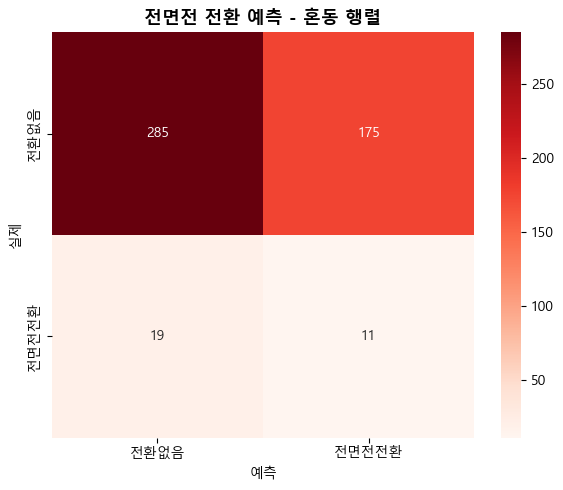

In [6]:
# ====================================================
# 셀 6: 평가
#
# 핵심 지표: 재현율(Recall)
#   전면전 전환을 놓치면 안 되니까
#   정확도보다 재현율이 더 중요!
# ====================================================
# 임계값 0.3 사용 (기본 0.5보다 낮춤)
# → 전환 가능성 30% 이상이면 전환으로 예측 (더 민감하게)
THRESHOLD = 0.3

y_prob = model.predict([X_text_te, X_num_te], verbose=0).flatten()
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f'📊 전면전 전환 예측 모델 평가 (임계값={THRESHOLD})')
print('='*50)
print(classification_report(y_te, y_pred,
                             target_names=['전환없음', '전면전전환']))

# 혼동 행렬
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['전환없음','전면전전환'],
            yticklabels=['전환없음','전면전전환'])
plt.title('전면전 전환 예측 - 혼동 행렬', fontsize=13, fontweight='bold')
plt.ylabel('실제'); plt.xlabel('예측')
plt.tight_layout()
plt.savefig('plots/escalation_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

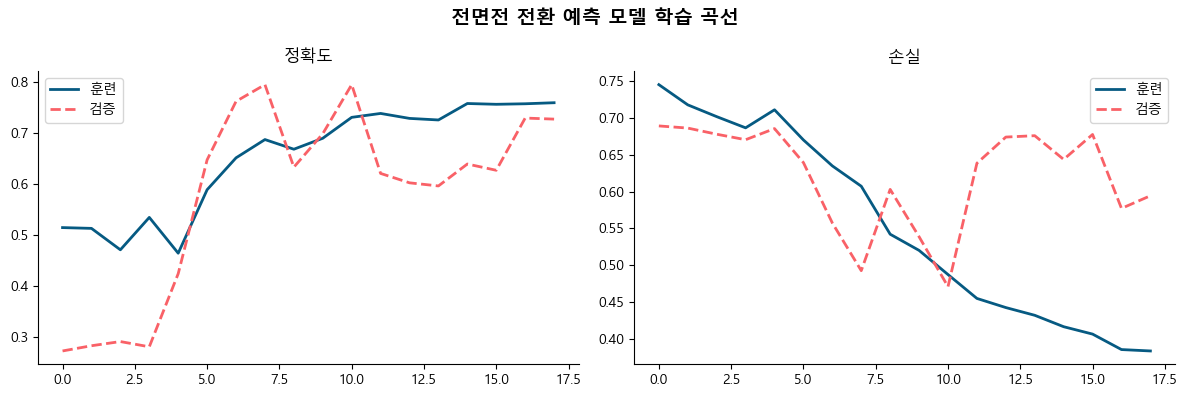

In [7]:
# ====================================================
# 셀 7: 학습 곡선
# ====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('전면전 전환 예측 모델 학습 곡선', fontsize=14, fontweight='bold')

ax1.plot(history.history['accuracy'],     label='훈련', color='#065A82', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='검증', color='#F96167', linewidth=2, linestyle='--')
ax1.set_title('정확도'); ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.plot(history.history['loss'],     label='훈련', color='#065A82', linewidth=2)
ax2.plot(history.history['val_loss'], label='검증', color='#F96167', linewidth=2, linestyle='--')
ax2.set_title('손실'); ax2.legend(); ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/escalation_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 저장 & 예측 테스트

In [8]:
# ====================================================
# 셀 8: 모델 저장
# ====================================================
model.save('models/escalation_predictor.keras')
with open('models/tokenizer_escalation.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('models/scaler_escalation.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ 저장 완료')
print('   models/escalation_predictor.keras')
print('   models/tokenizer_escalation.pkl')
print('   models/scaler_escalation.pkl')

✅ 저장 완료
   models/escalation_predictor.keras
   models/tokenizer_escalation.pkl
   models/scaler_escalation.pkl


In [9]:
# ====================================================
# 셀 9: 예측 함수 & 테스트
#
# 앱에서 사용할 예측 함수
# 텍스트 + 사망자 수치를 넣으면
# 전면전 전환 확률(%)을 출력
# ====================================================

def predict_escalation(location, side_a, side_b,
                        conflict_type, cause,
                        deaths, deaths_prev=0, duration=1):
    """전면전 전환 확률 예측
    
    Args:
        location:      발생지 (예: '우크라이나')
        side_a:        교전A (예: '우크라이나 정부')
        side_b:        교전B (예: '러시아')
        conflict_type: 분쟁유형 (예: '내전')
        cause:         분쟁원인 (예: '영토')
        deaths:        올해 사망자 수
        deaths_prev:   전년도 사망자 수
        duration:      분쟁 지속 연수
    
    Returns:
        전면전 전환 확률 (%)
    """
    # 텍스트 처리
    text = f'{location} {side_a} {side_b} {conflict_type} {cause}'
    seq  = tokenizer.texts_to_sequences([text])
    pad  = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    # 수치 처리
    numeric = scaler.transform([[deaths, deaths-deaths_prev, duration]])

    # 예측
    prob = model.predict([pad, numeric], verbose=0)[0][0]
    return float(prob) * 100


# 테스트
test_cases = [
    ('우크라이나', '우크라이나 정부', '러시아', '국제화내전', '영토', 50000, 10000, 2),
    ('시리아',     '시리아 정부',     'ISIS',   '내전',       '정부/권력', 5000, 3000, 10),
    ('인도',       '인도 정부',       'GNLA',   '내전',       '영토', 27, 25, 15),
]

print('🔍 전면전 전환 확률 예측 테스트')
print('='*55)
for loc, a, b, ctype, cause, d, dp, dur in test_cases:
    prob = predict_escalation(loc, a, b, ctype, cause, d, dp, dur)
    bar  = '█' * int(prob/5) + '░' * (20-int(prob/5))
    print(f'\n📌 {loc}')
    print(f'   사망자: {d:,}명 | 지속: {dur}년')
    print(f'   전면전 전환 확률: {prob:.1f}%')
    print(f'   [{bar}]')

print('\n✅ 완료!')
print('▶ 다음: app.py에서 이 예측 함수를 연결하면 시연 가능!')

🔍 전면전 전환 확률 예측 테스트

📌 우크라이나
   사망자: 50,000명 | 지속: 2년
   전면전 전환 확률: 0.0%
   [░░░░░░░░░░░░░░░░░░░░]

📌 시리아
   사망자: 5,000명 | 지속: 10년
   전면전 전환 확률: 30.7%
   [██████░░░░░░░░░░░░░░]

📌 인도
   사망자: 27명 | 지속: 15년
   전면전 전환 확률: 12.2%
   [██░░░░░░░░░░░░░░░░░░]

✅ 완료!
▶ 다음: app.py에서 이 예측 함수를 연결하면 시연 가능!
